# QED-C Application-Oriented Benchmarks - MQT Bench Example
The notebook demonstrates modularized problem generation using MQT Bench; execution and analysis are done using the QED-C suite.  

The list of MQT Bench algorithmic benchmarks can be found at the following website: https://mqt.readthedocs.io/projects/bench/en/latest/benchmark_selection.html.

Configure and run the cell below with the desired execution settings, then proceed to run the remaining cells.

In [1]:
benchmark_name = 'qnn'
min_qubits=4
max_qubits=14
skip_qubits=2
max_circuits=3
num_shots=1000

In [2]:
# MQT Bench:
from mqt.bench import get_benchmark, BenchmarkLevel

# QED-C:
from _common import metrics
from _common.qiskit import execute as ex

# IBM Qiskit:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator

## Part 1: Problem Generation with MQT Bench
The code below grabs __circuits__ from MQT Bench from _min_qubits_ to _max_qubits_ using _skip_qubits_ and _max_circuits_. 

In [3]:
def get_mqt_circuits(
    benchmark_name:str, 
    min_qubits:int, 
    max_qubits:int, 
    skip_qubits:int, 
    max_circuits:int
    ):
    circuits = {}
    for n_qubits in range(min_qubits, max_qubits+1, skip_qubits):
        circuits_n_qubits = {}
        for idx in range(1, max_circuits+1):
            circuits_n_qubits[str(idx)] = get_benchmark(benchmark=benchmark_name, level=BenchmarkLevel.ALG, circuit_size=n_qubits)
        circuits[str(n_qubits)] = circuits_n_qubits
    return circuits

In [4]:
# Using the above function to grab circuits. 
circuits = get_mqt_circuits(benchmark_name, min_qubits, max_qubits, skip_qubits, max_circuits)

In [5]:
print(f"\nCircuits:\n{circuits}")


Circuits:
{'4': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10e82fb00>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10e85af00>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10e85bfb0>}, '6': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10e85b2c0>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10e871130>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10e8726f0>}, '8': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10e85b950>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10e870650>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10e85b410>}, '10': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10e872390>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10e871d00>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10e88f470>}, '12': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit o

## Part 2: Execution

Now that we have the Qiskit circuits, we execute them using QED-C's execution module. 

In [6]:
backend_id="qasm_simulator"
hub=""; group=""; project=""
provider_backend = None
exec_options = {}
context = f"{benchmark_name} Benchmark"

In [7]:
def ideal_dist(
    flat_circuits: list[QuantumCircuit],
    num_shots: int
):
    """Computes the ideal distribution to compare results to by running on a noiseless simulator."""
    sim = Aer.get_backend("aer_simulator")
    tqc = transpile(flat_circuits, sim)
    result = sim.run(tqc, shots=num_shots).result()
    return result.get_counts()
    
def execution_handler(qc, result, num_qubits, circuit_id, num_shots):
    """Process results and store fidelities after execution."""
    correct = ideal_dist([qc], num_shots)
    # Compute the fidelity
    hf_fidelity = metrics.hellinger_fidelity_with_expected(result.get_counts(), correct) 
    polarization_fidelity = metrics.polarization_fidelity(result.get_counts(), correct)
    # Store the fidelity.
    metrics.store_metric(num_qubits, circuit_id, "hf_fidelity", hf_fidelity)
    metrics.store_metric(num_qubits, circuit_id, "fidelity", polarization_fidelity)

In [8]:
ex.init_execution(execution_handler)
ex.set_execution_target(backend_id, provider_backend=provider_backend,
        hub=hub, group=group, project=project, exec_options=exec_options,
        context=context)

# Submit circuits
for num_qubits in circuits.keys():
    for circuit_id in circuits[num_qubits].keys():
        qc = circuits[num_qubits][circuit_id]
        ex.submit_circuit(qc, num_qubits, circuit_id, shots=num_shots)

ex.throttle_execution(metrics.finalize_group)
ex.finalize_execution(metrics.finalize_group)

/Users/neerpatel/miniforge3/envs/qedc/lib/python3.12/site-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 10, 0.111
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 8, 0.158, 3.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0, 0.832, 0.002 secs
Average Transpiling, Validating, Running Times for group 4 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.991, 0.983

************
Average Circuit Algorithmic Depth, ξ (xi) for the 6 qubit group = 12, 0.122
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 6 qubit group = 10, 0.172, 5.0
Average Creation, Elapsed, Execution Time for the 6 qubit group = 0, 1.889, 0.004 secs
Average Transpiling, Validating, Running Times for group 6 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 6 qubit group = 0.966, 0.936

************
Average Circuit Algorithmic Depth, ξ (xi) for the 8 qubit group = 14, 0.127
Average Normalized Transpiled Depth, ξ (xi), 2q 

## Part 3: Analysis and Results
After executing the circuits, we can plot the results.

### Visualization

Now that the fidelities are stored, we can use the metrics module to create plots. 

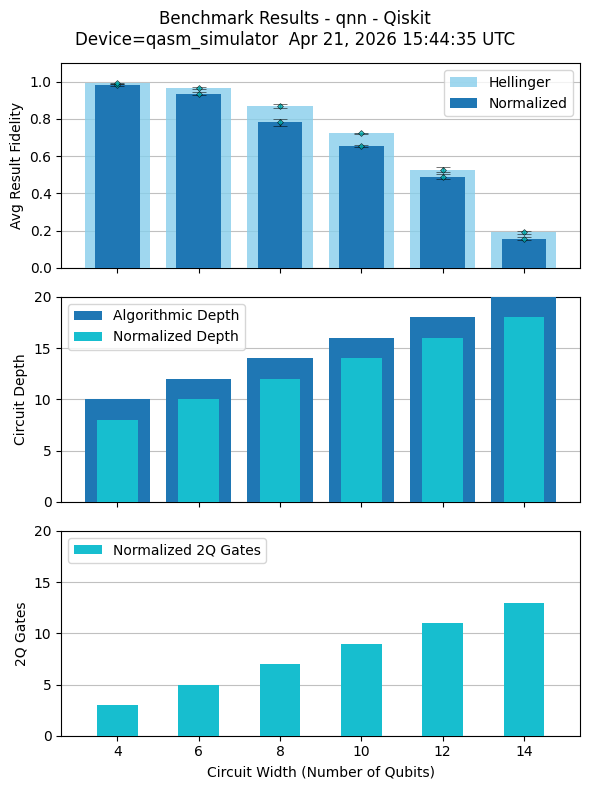

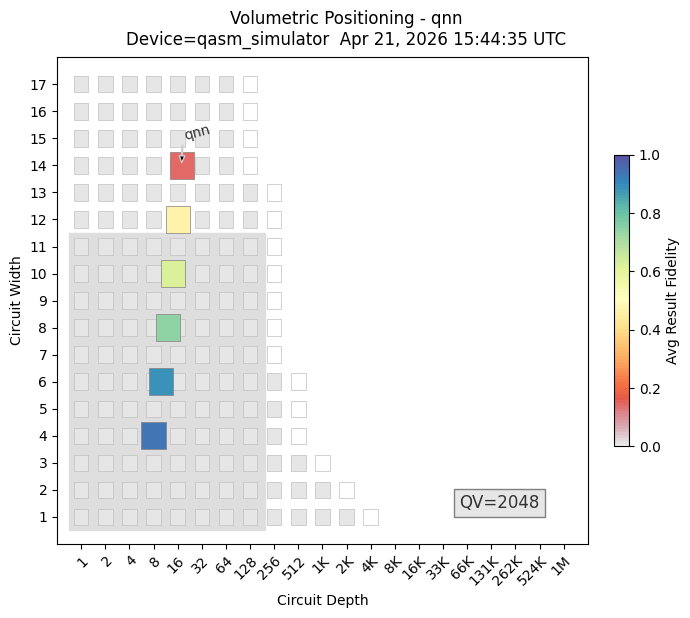

In [9]:
# Set information for plot titles.
benchmark_name = benchmark_name
provider_name = "Qiskit"
device_name = "qasm_simulator"

# Set plot titles.
benchmark_title = f"{benchmark_name}"
subtitle = f"Benchmark Results - {benchmark_title} - {provider_name}"
metrics.circuit_metrics["subtitle"] = f"device = {device_name}"

# Determine which metrics to plot.
filters = ["fidelity", "hf_fidelity", "depth", "2q", "vbplot"]

# Plot the metrics.
metrics.plot_metrics(subtitle, filters=filters)

Number of Qubits: 4


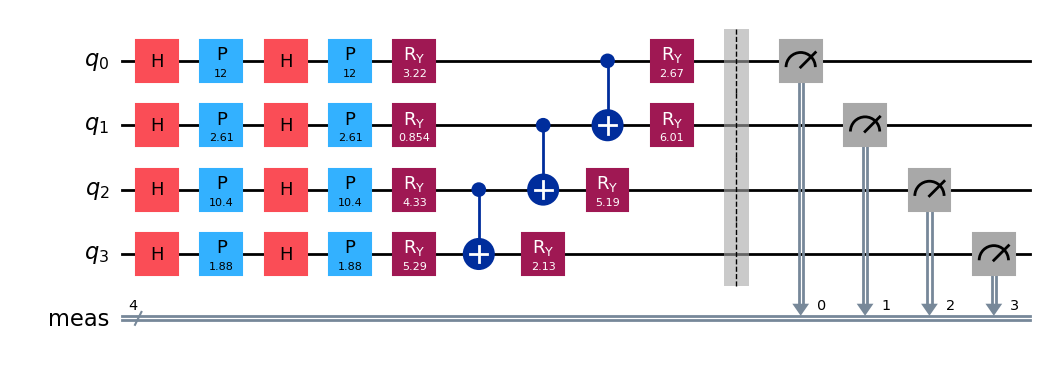

Number of Qubits: 6


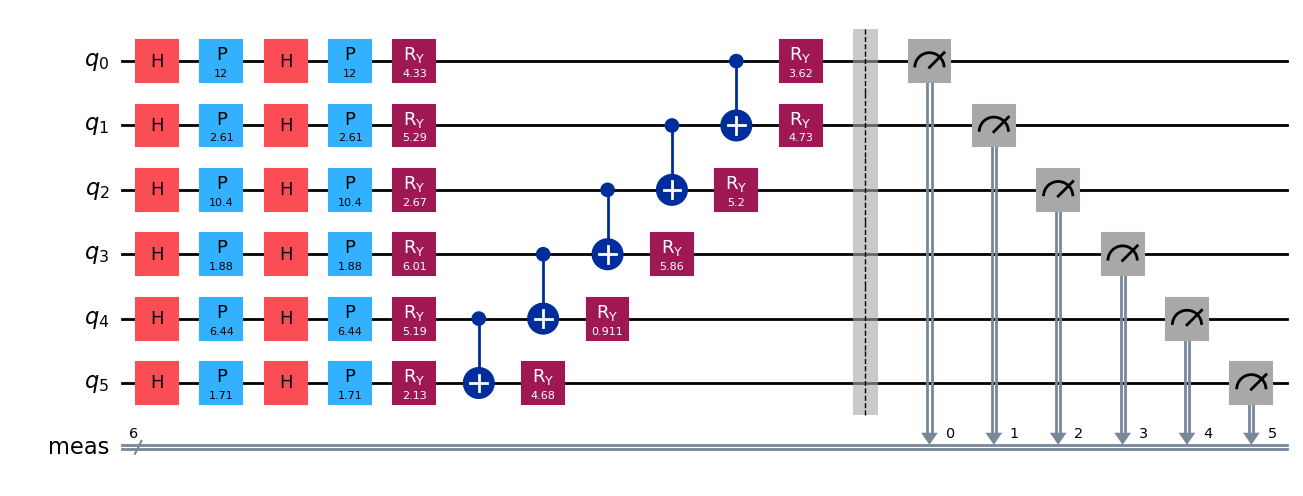

Number of Qubits: 8


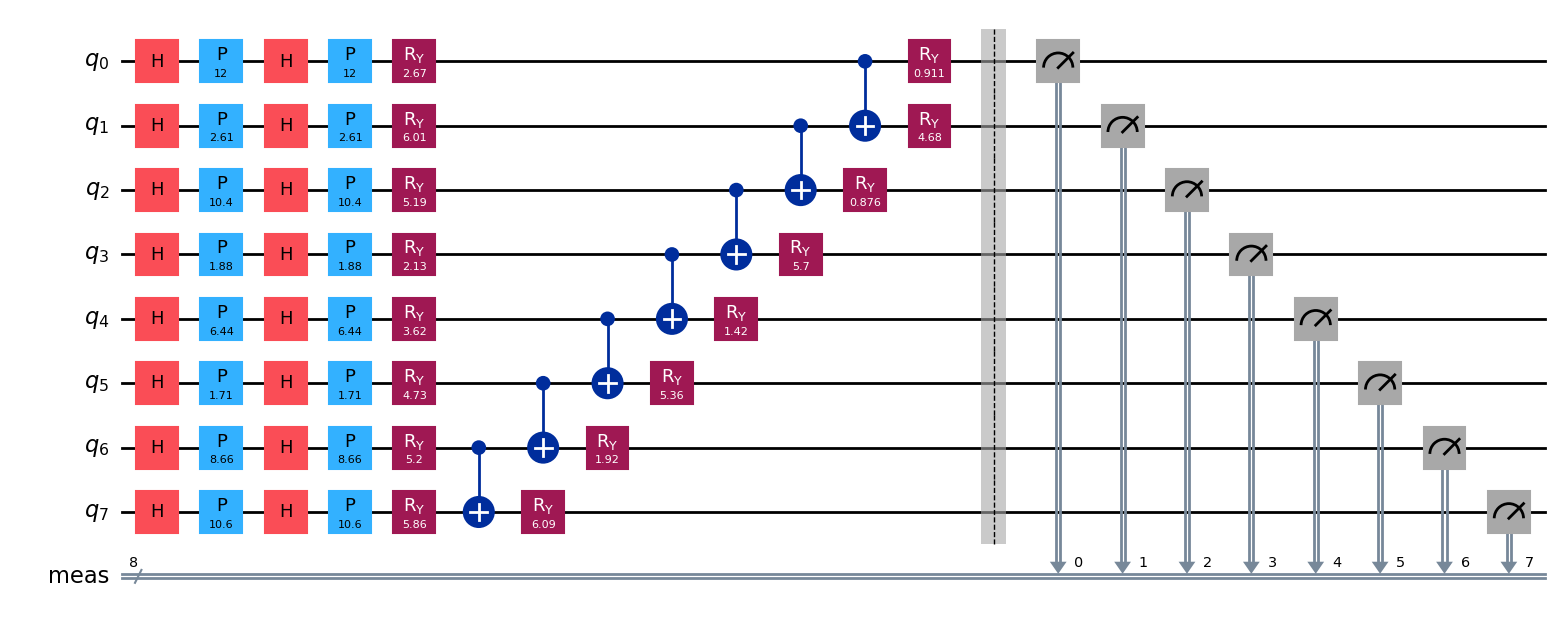

Number of Qubits: 10


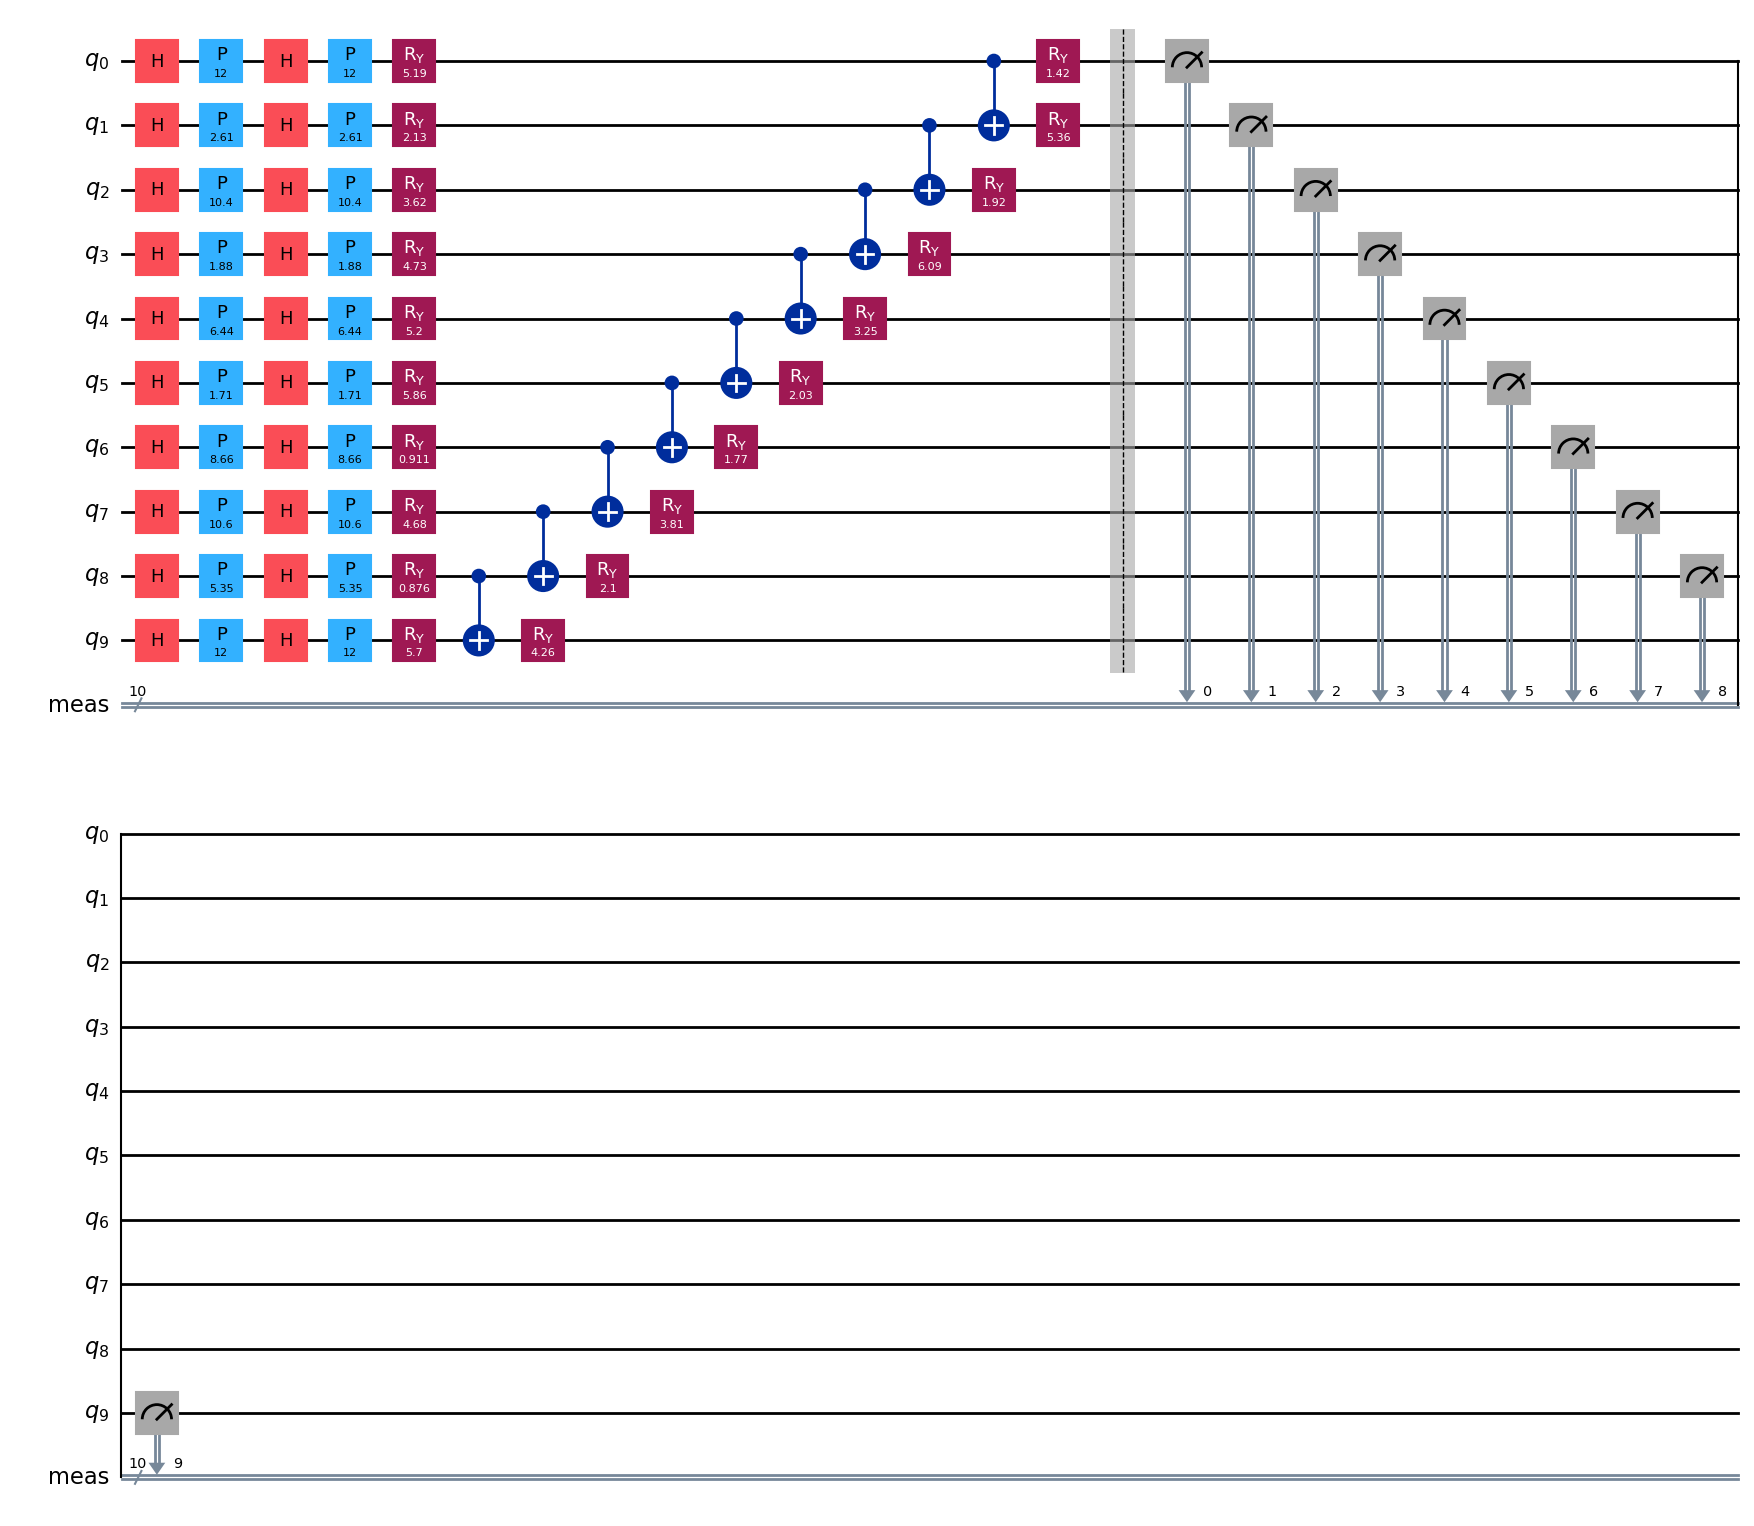

Number of Qubits: 12


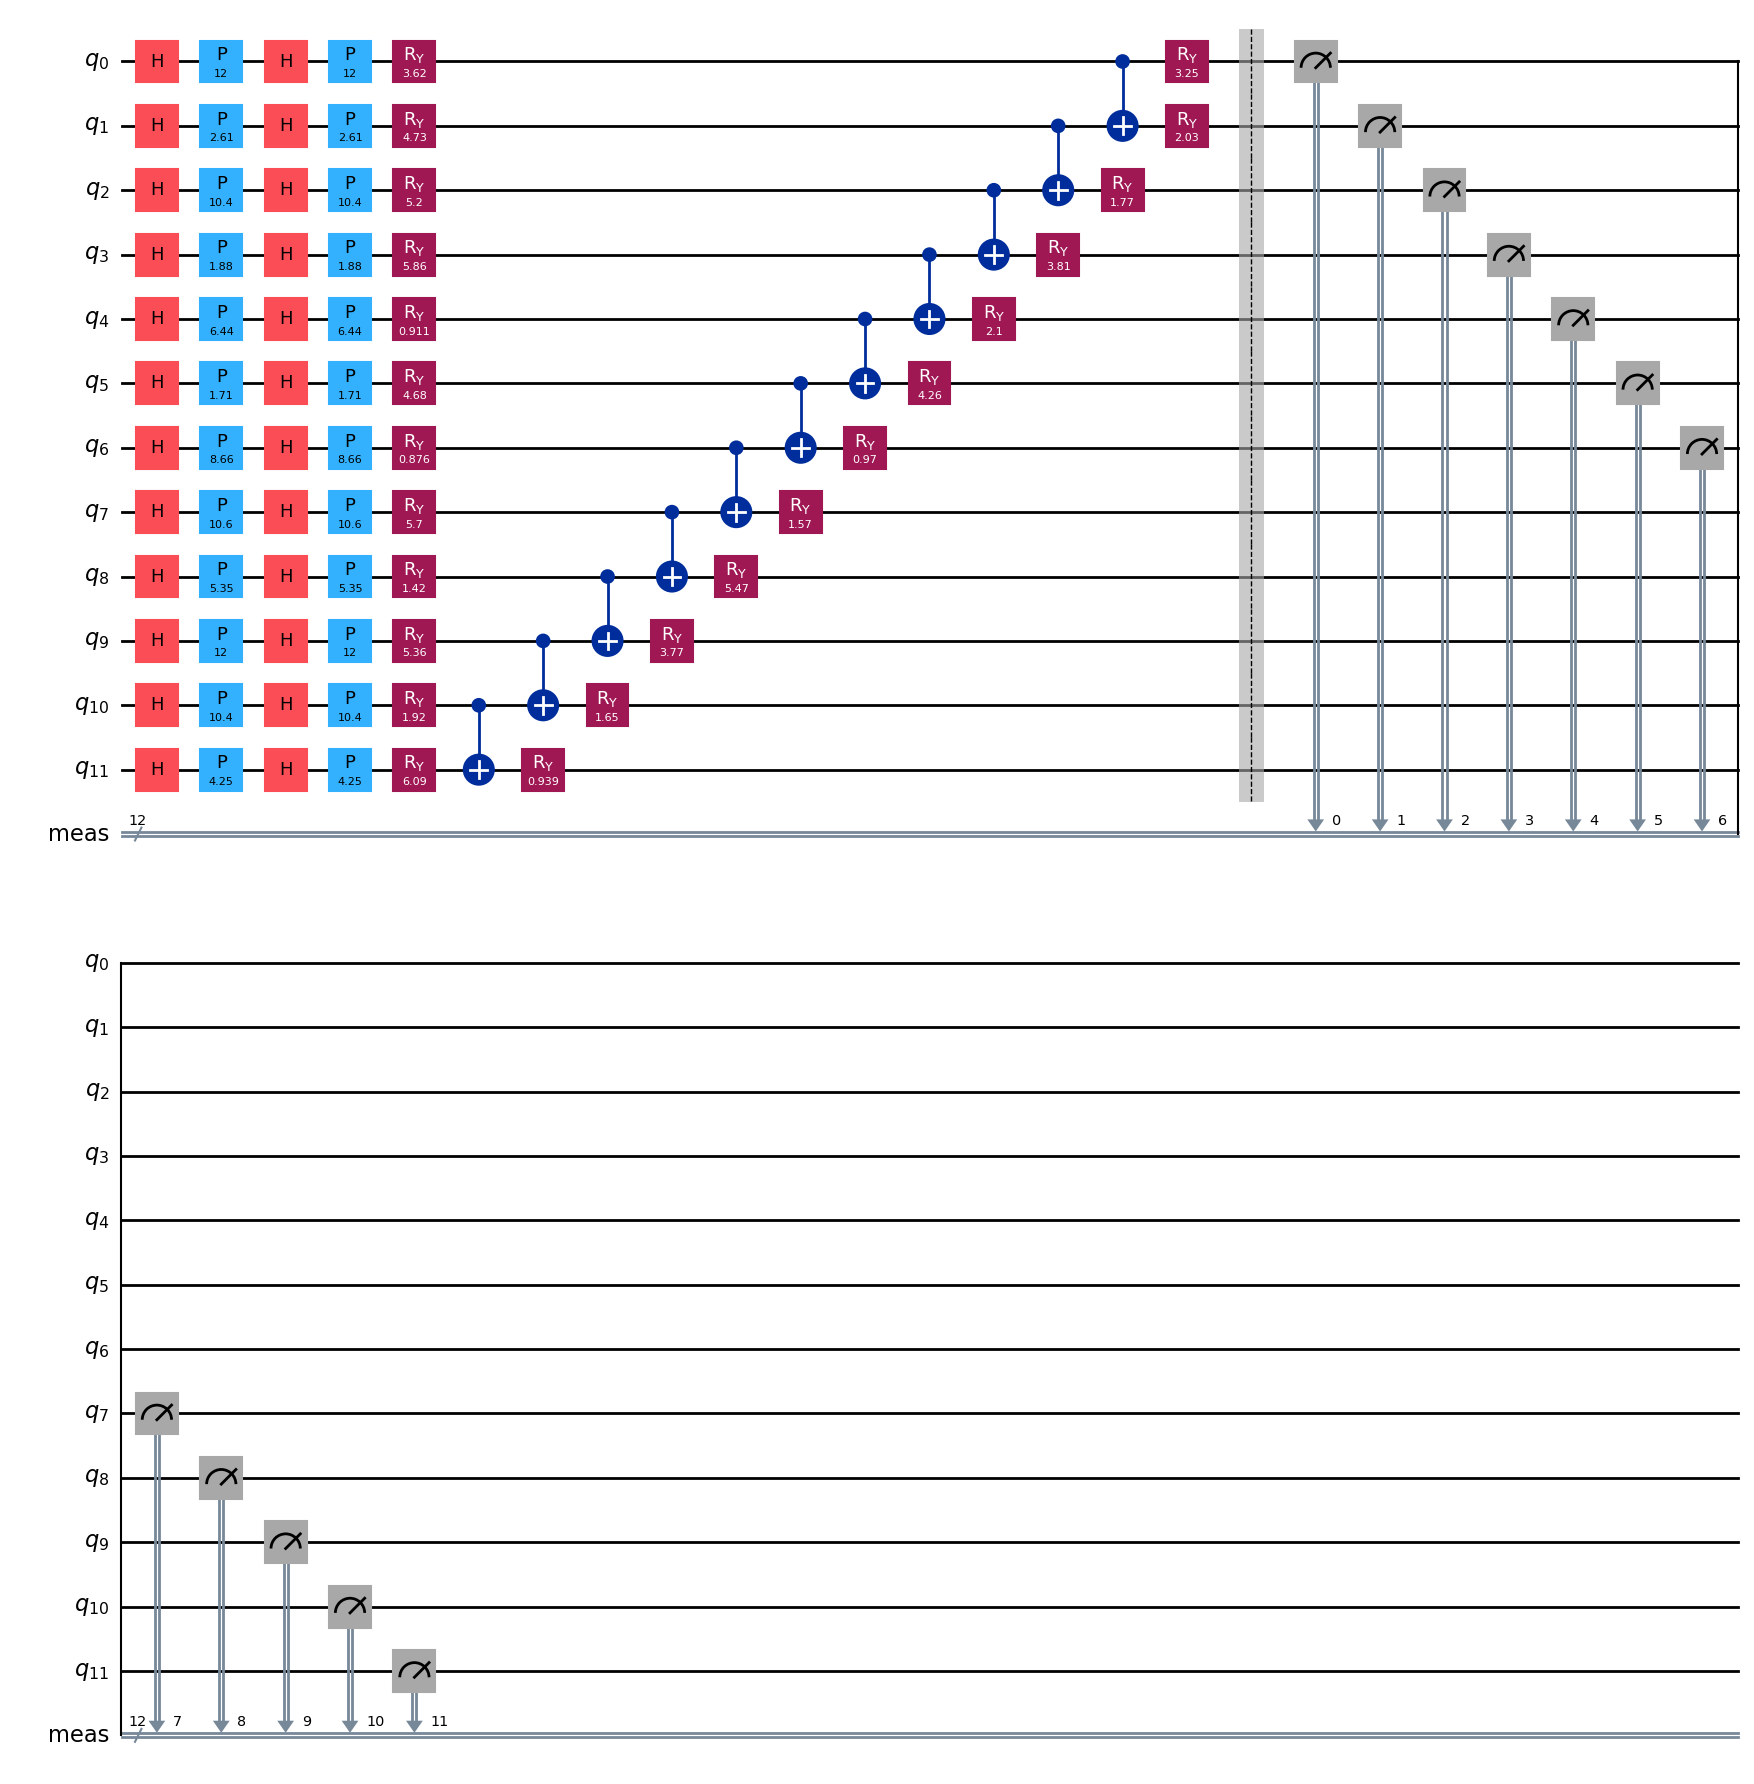

Number of Qubits: 14


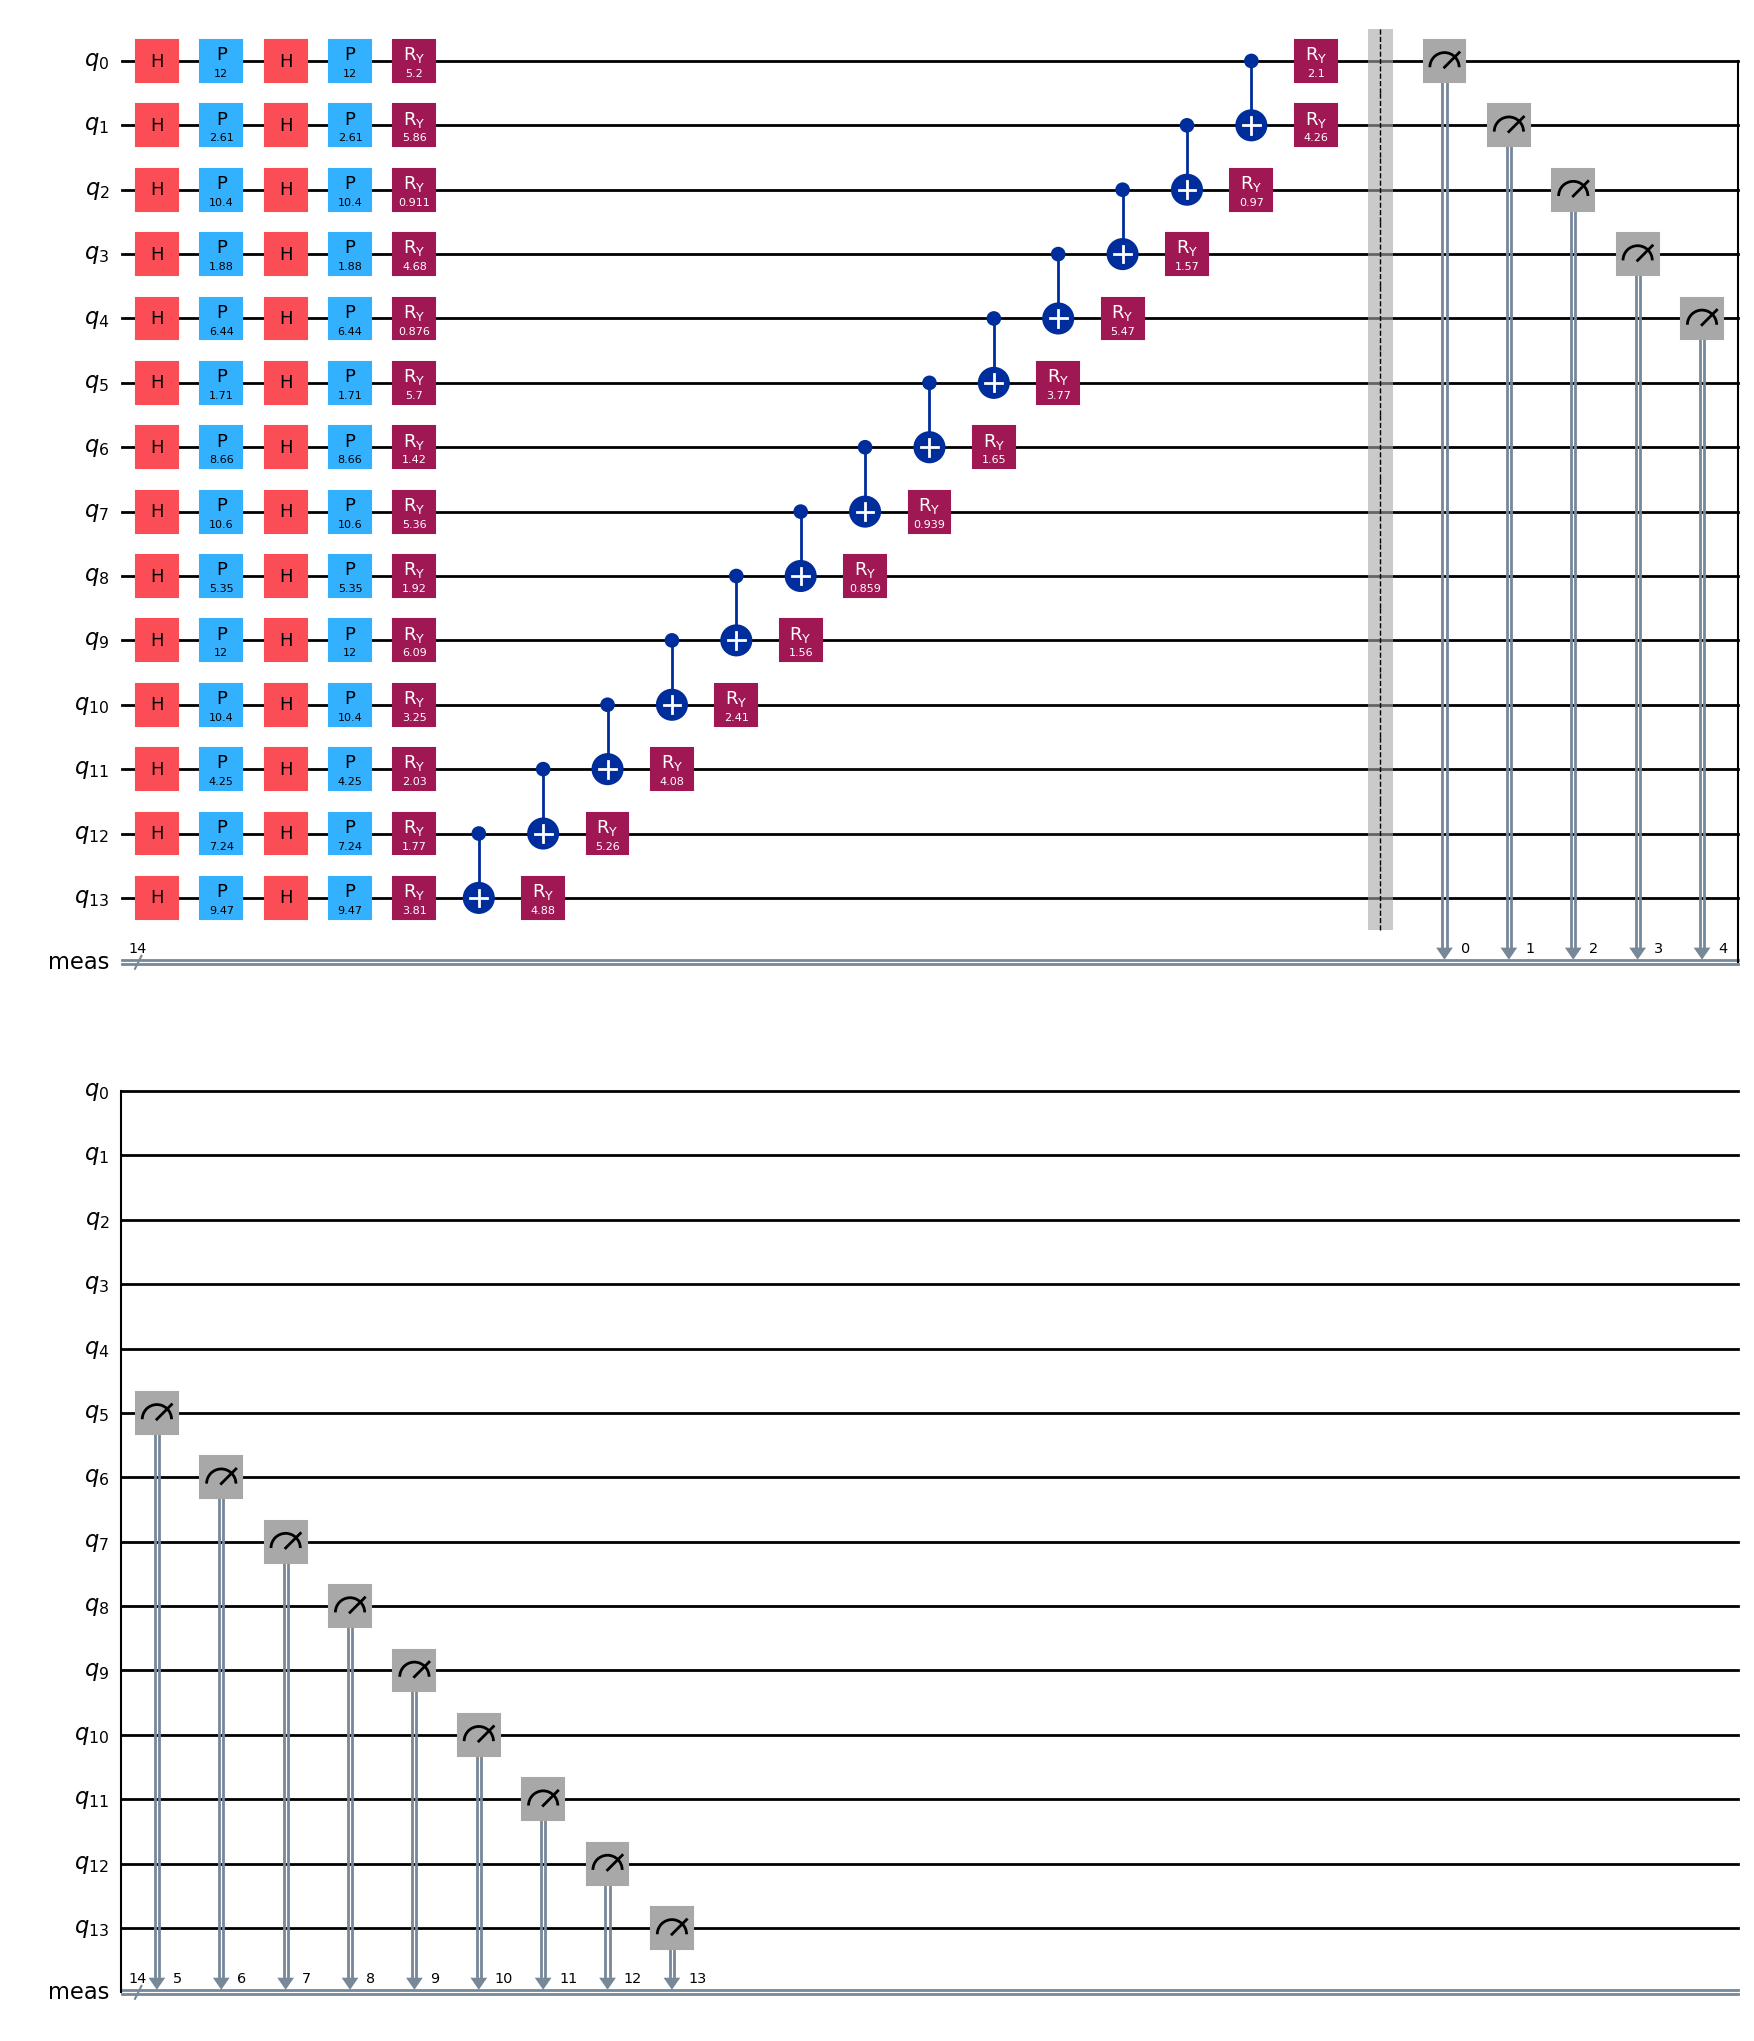

In [10]:
# Visualize the first circuit for each qubit size.
for num_qubits in circuits.keys():
    for circuit_id in circuits[num_qubits].keys():
        qc = circuits[num_qubits][circuit_id]
        print(f"Number of Qubits: {num_qubits}")
        display(qc.draw(output='mpl'))
        break